# Recommended substations vs. labeled ground truth

The optimizer's "existing substations" come from a satellite detection model, which can be wrong. If a model error missed a real substation, the optimizer may recommend building a new one where a substation already exists.

This notebook checks how many of the optimizer's recommended new builds in Maricopa County overlap with labeled (positive) substations in `metadata.csv`.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import KDTree

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT = BASE_DIR / "preloaded_demo_output" / "maricopa_new_substations.csv"
METADATA = BASE_DIR / "preloaded_demo_output" / "maricopa" / "metadata.csv"
COUNTY_GEOID = 4013  # Maricopa
CRS_PROJ = "EPSG:32612"  # UTM 12N — matches optimizer

recs = pd.read_csv(OUTPUT)
meta = pd.read_csv(METADATA)
print(f"Recommendations: {len(recs)}")
print(f"Metadata rows: {len(meta):,}")

Recommendations: 50
Metadata rows: 194


In [6]:
# Labeled substations in Maricopa (both positive detections AND any positive ground-truth label)
maricopa = meta[meta["county_geoid"] == COUNTY_GEOID].copy()
print(f"Maricopa rows total:     {len(maricopa):,}")
print(f"  label == positive:     {(maricopa['label'] == 'positive').sum():,}")
print(f"  substation_type set:   {maricopa['substation_type'].notna().sum():,}")

# "True" substations: rows the ground-truth labeling marked positive.
# Using label == 'positive' matches how the optimizer consumes metadata.
truth = maricopa[maricopa["label"] == "positive"].copy()
truth.head()

Maricopa rows total:     194
  label == positive:     194
  substation_type set:   194


,patch_id,label,center_lon,center_lat,county_geoid,positive_pixels,area_m2,mean_confidence,max_confidence,bbox_width_m,bbox_height_m,voltage,substation_type,substation_name,operator,osm_id,geom_source,source,split
0,patch_0333767_1120845,positive,-112.084796,33.376711,4013,46253,16651.08,0.937552,1.000000,121.8,169.8,NaN,detected,NaN,NaN,-1,model,local_inference,prediction
1,patch_0333685_1120745,positive,-112.074318,33.367787,4013,2124,764.64,0.657800,0.793945,33.6,36.6,NaN,detected,NaN,NaN,-1,model,local_inference,prediction
2,patch_0333629_1120777,positive,-112.078381,33.363598,4013,1058,380.88,0.558287,0.599121,31.2,28.8,NaN,detected,NaN,NaN,-1,model,local_inference,prediction
3,patch_0333683_1120284,positive,-112.027415,33.368349,4013,1712,616.32,0.630727,0.893555,27.0,37.8,NaN,detected,NaN,NaN,-1,model,local_inference,prediction
4,patch_0333658_1121320,positive,-112.132121,33.365371,4013,3038,1093.68,0.626698,0.912598,43.8,51.0,NaN,detected,NaN,NaN,-1,model,local_inference,prediction


In [7]:
# Project both sets to UTM so distances are in meters
recs_gdf = gpd.GeoDataFrame(
    recs, geometry=gpd.points_from_xy(recs["lon"], recs["lat"]), crs="EPSG:4326"
).to_crs(CRS_PROJ)

truth_gdf = gpd.GeoDataFrame(
    truth,
    geometry=gpd.points_from_xy(truth["center_lon"], truth["center_lat"]),
    crs="EPSG:4326",
).to_crs(CRS_PROJ)

rec_xy = np.column_stack([recs_gdf.geometry.x, recs_gdf.geometry.y])
truth_xy = np.column_stack([truth_gdf.geometry.x, truth_gdf.geometry.y])

tree = KDTree(truth_xy)
dists, idxs = tree.query(rec_xy, k=1)

recs_gdf["nearest_truth_m"] = dists
recs_gdf["nearest_truth_patch_id"] = truth.iloc[idxs]["patch_id"].values

In [8]:
# Overlap counts at several thresholds
thresholds_m = [250, 500, 1000, 2000, 5000]
print(f"{'Threshold':>12}  {'Recs within':>12}  {'% of recs':>10}")
for t in thresholds_m:
    n = int((recs_gdf["nearest_truth_m"] <= t).sum())
    print(f"{t:>9} m    {n:>9} / {len(recs_gdf):<3}  {n/len(recs_gdf)*100:>9.1f}%")

   Threshold   Recs within   % of recs
      250 m            0 / 50         0.0%
      500 m            0 / 50         0.0%
     1000 m           21 / 50        42.0%
     2000 m           41 / 50        82.0%
     5000 m           49 / 50        98.0%


In [9]:
# Distribution of distances from each recommendation to its nearest labeled substation
print(recs_gdf["nearest_truth_m"].describe().round(0))

count      50.0
mean     1568.0
std      1185.0
min       501.0
25%       857.0
50%      1180.0
75%      1653.0
max      6065.0
Name: nearest_truth_m, dtype: float64


In [10]:
# Suspicious recommendations: within 500 m of a labeled substation — likely a model miss
overlap_threshold_m = 500
flagged = recs_gdf[recs_gdf["nearest_truth_m"] <= overlap_threshold_m].sort_values(
    "nearest_truth_m"
)
print(f"{len(flagged)} recommendations within {overlap_threshold_m} m of a labeled substation:")
flagged[[
    "candidate_id", "lat", "lon", "total_load_kw",
    "nearest_truth_m", "nearest_truth_patch_id",
]]

0 recommendations within 500 m of a labeled substation:


,candidate_id,lat,lon,total_load_kw,nearest_truth_m,nearest_truth_patch_id


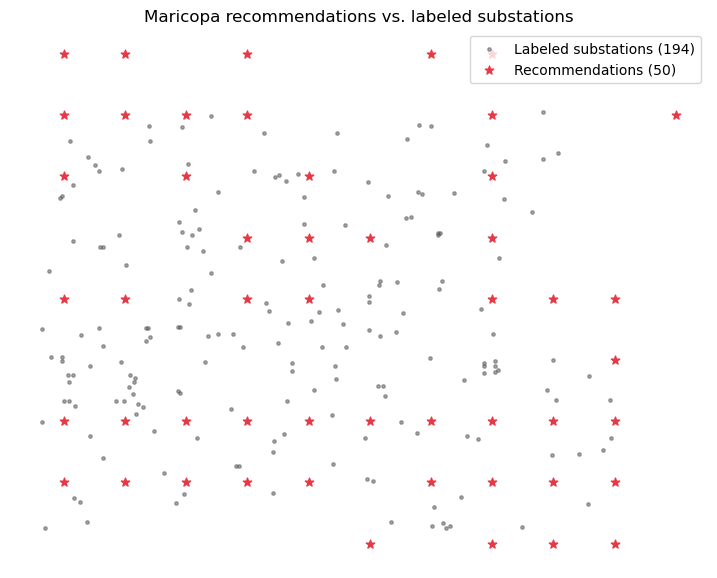

In [11]:
# Quick map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 9))
truth_gdf.plot(ax=ax, color="#555555", markersize=6, alpha=0.5, label=f"Labeled substations ({len(truth_gdf)})")
recs_gdf.plot(ax=ax, color="#e63946", markersize=40, marker="*", label=f"Recommendations ({len(recs_gdf)})")
if len(flagged):
    flagged_gdf = recs_gdf.loc[flagged.index]
    flagged_gdf.plot(ax=ax, facecolor="none", edgecolor="orange", markersize=200,
                     linewidth=1.5, label=f"Within {overlap_threshold_m} m ({len(flagged)})")
ax.legend()
ax.set_title("Maricopa recommendations vs. labeled substations")
ax.set_axis_off()
plt.show()

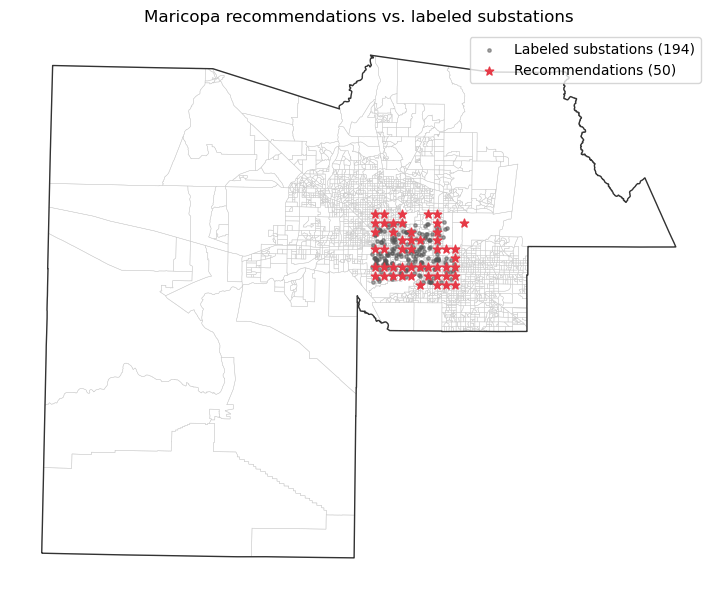

In [14]:
 # Quick map
import matplotlib.pyplot as plt

# County geography from TIGER block groups
STATE_FIPS = "04"
COUNTY_FIPS = "013"
tiger_dir = BASE_DIR / "data" / f"tl_2025_{STATE_FIPS}_bg"
shp = next(tiger_dir.glob("*.shp"))
bg = gpd.read_file(shp)
bg = bg[(bg["STATEFP"] == STATE_FIPS) & (bg["COUNTYFP"] == COUNTY_FIPS)].to_crs(CRS_PROJ)
county_outline = bg.dissolve()

fig, ax = plt.subplots(figsize=(9, 9))
bg.boundary.plot(ax=ax, color="#cccccc", linewidth=0.3, zorder=1)
county_outline.boundary.plot(ax=ax, color="#333333", linewidth=1.0, zorder=2)
truth_gdf.plot(ax=ax, color="#555555", markersize=6, alpha=0.5, zorder=3,
                label=f"Labeled substations ({len(truth_gdf)})")
recs_gdf.plot(ax=ax, color="#e63946", markersize=40, marker="*", zorder=4,
            label=f"Recommendations ({len(recs_gdf)})")
if len(flagged):
    flagged_gdf = recs_gdf.loc[flagged.index]
    flagged_gdf.plot(ax=ax, facecolor="none", edgecolor="orange", markersize=200,
                    linewidth=1.5, zorder=5,
                    label=f"Within {overlap_threshold_m} m ({len(flagged)})")
ax.legend()
ax.set_title("Maricopa recommendations vs. labeled substations")
ax.set_axis_off()
plt.show()

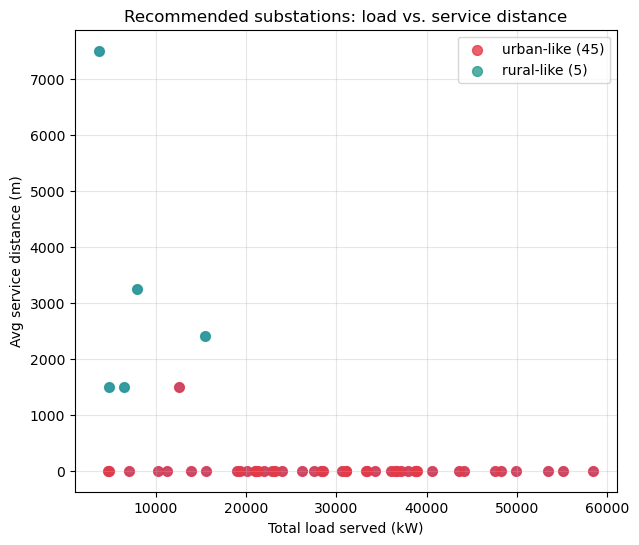

cluster
urban-like    45
rural-like     5
Name: count, dtype: int64


In [15]:
 # Scatter: load served vs. average service distance
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(recs_gdf["total_load_kw"], recs_gdf["avg_service_dist_m"],
            s=40, color="#2563eb", alpha=0.7)
ax.set_xlabel("Total load served (kW)")
ax.set_ylabel("Avg service distance (m)")
ax.set_title("Recommended substations: load vs. service distance")
ax.grid(True, alpha=0.3)

# Simple axis-proximity cluster: normalize each axis to [0, 1], then compare
# distance-to-x-axis (low y, high load  -> "urban-like") vs.
# distance-to-y-axis (low load, high dist -> "rural-like").
load_n = recs_gdf["total_load_kw"] / recs_gdf["total_load_kw"].max()
dist_n = recs_gdf["avg_service_dist_m"] / recs_gdf["avg_service_dist_m"].max()
# Closer to x-axis => small dist_n; closer to y-axis => small load_n.
recs_gdf["cluster"] = np.where(dist_n < load_n, "urban-like", "rural-like")

for name, color in [("urban-like", "#e63946"), ("rural-like", "#2a9d8f")]:
    sub = recs_gdf[recs_gdf["cluster"] == name]
    ax.scatter(sub["total_load_kw"], sub["avg_service_dist_m"],
                s=50, color=color, alpha=0.8, label=f"{name} ({len(sub)})")
ax.legend()
plt.show()

print(recs_gdf["cluster"].value_counts())

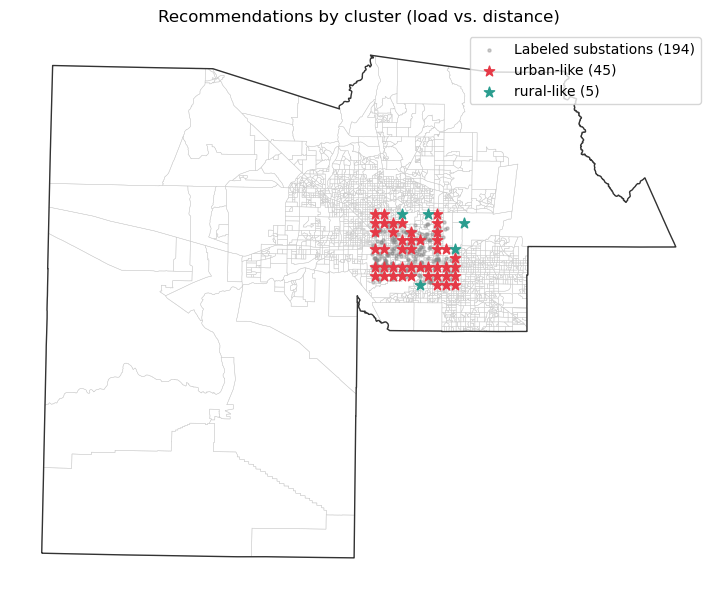

In [16]:
fig, ax = plt.subplots(figsize=(9, 9))
bg.boundary.plot(ax=ax, color="#cccccc", linewidth=0.3, zorder=1)
county_outline.boundary.plot(ax=ax, color="#333333", linewidth=1.0, zorder=2)
truth_gdf.plot(ax=ax, color="#888888", markersize=5, alpha=0.4, zorder=3,
                label=f"Labeled substations ({len(truth_gdf)})")
for name, color in [("urban-like", "#e63946"), ("rural-like", "#2a9d8f")]:
    sub = recs_gdf[recs_gdf["cluster"] == name]
    sub.plot(ax=ax, color=color, markersize=60, marker="*", zorder=4,
            label=f"{name} ({len(sub)})")
ax.legend()
ax.set_title("Recommendations by cluster (load vs. distance)")
ax.set_axis_off()
plt.show()